These four columns represent the felt/impact measurements of each earthquake event:
- **cdi** — Community Decimal Intensity (how strongly people reported feeling it)
- **mmi** — Modified Mercalli Intensity (instrumental measure of shaking)
- **tsunami** — Whether the event triggered a tsunami (0 or 1)
- **sig** — Overall significance score assigned to the event

This notebook is designed to create a siesmic impact concat for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Dark theme for all charts
plt.style.use('dark_background')
ACCENT  = '#fd8d3c'   # orange
ACCENT2 = '#4575b4'   # blue
RED     = '#bd0026'
GRID    = '#2a2a3d'

In [2]:
# Load Data

df = pd.read_csv("data/merged_earthquake_data.csv")
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
df['month']     = df['date_time'].dt.month_name()
df['month_num'] = df['date_time'].dt.month
df['year']      = df['date_time'].dt.year

# Magnitude categories based on actual data range (6.5 - 9.1)
def mag_category(m):
    if m < 6.5:  return 'Strong'
    elif m < 7.0: return 'Major'
    elif m < 7.5: return 'Great'
    else:         return 'Extreme'

df['magnitude_category'] = df['magnitude'].apply(mag_category)
category_order = ['Strong', 'Major', 'Great', 'Extreme']
month_order    = ['January','February','March','April','May','June',
                  'July','August','September','October','November','December']

print(f'Loaded {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Loaded 1782 rows x 23 columns


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,...,depth,latitude,longitude,location,continent,country,month,month_num,year,magnitude_category
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,...,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu,August,8,2023,Major
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,...,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN,July,7,2023,Major
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,...,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,July,7,2023,Major
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,...,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN,July,7,2023,Great
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,orange,1,820,at,79,...,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN,July,7,2023,Great


In [3]:
df_cdi     = df[['cdi']].copy()
df_mmi     = df[['mmi']].copy()
df_tsunami = df[['tsunami']].copy()
df_sig     = df[['sig']].copy()

print('cdi shape:    ', df_cdi.shape)
print('mmi shape:    ', df_mmi.shape)
print('tsunami shape:', df_tsunami.shape)
print('sig shape:    ', df_sig.shape)

cdi shape:     (1782, 1)
mmi shape:     (1782, 1)
tsunami shape: (1782, 1)
sig shape:     (1782, 1)


In [4]:
df_impact = pd.concat([df_cdi, df_mmi, df_tsunami, df_sig], axis=1)

print(f'Impact DataFrame shape: {df_impact.shape}')
df_impact.head(10)

Impact DataFrame shape: (1782, 4)


,cdi,mmi,tsunami,sig
0,7,4,0,657
1,8,6,0,775
2,7,5,0,899
3,6,6,1,860
4,0,5,1,820
5,5,4,1,802
6,4,4,1,741
7,8,6,1,804
8,6,6,1,733
9,3,4,1,777


In [5]:
print('--- Null counts ---')
print(df_impact.isnull().sum())

print('\n--- Data types ---')
print(df_impact.dtypes)

print('\n--- Basic stats ---')
df_impact.describe()

--- Null counts ---
cdi        0
mmi        0
tsunami    0
sig        0
dtype: int64

--- Data types ---
cdi        int64
mmi        int64
tsunami    int64
sig        int64
dtype: object

--- Basic stats ---


,cdi,mmi,tsunami,sig
count,1782.000000,1782.000000,1782.000000,1782.000000
mean,3.924804,5.999439,0.352974,857.654321
std,3.279248,1.446597,0.478029,311.145509
min,0.000000,1.000000,0.000000,650.000000
25%,0.000000,5.000000,0.000000,691.000000
50%,5.000000,6.000000,0.000000,749.000000
75%,7.000000,7.000000,1.000000,889.000000
max,9.000000,10.000000,1.000000,2910.000000


In [6]:
# Aggregation summarizing Seismic Impact data

print('    Overall Seismic Impact Stats    ')
print(df_impact.describe().round(3))

# Percentage of earthquakes that triggered a tsunami
tsunami_pct = (df_impact['tsunami'].sum() / len(df_impact) * 100).round(2)
print(f'\nTsunami Occurrence Rate: {tsunami_pct}% of all earthquakes')

# Group by tsunami flag to see how sig, cdi, mmi differ between tsunami and non tsunami events
print('\n    Mean Impact Metrics: Tsunami vs Non-Tsunami Events    ')
tsunami_group = df_impact.groupby('tsunami').agg(
    mean_cdi = ('cdi', 'mean'),
    mean_mmi = ('mmi', 'mean'),
    mean_sig = ('sig', 'mean'),
    count    = ('sig', 'count')
).round(3)

tsunami_group.index = ['No Tsunami', 'Tsunami']
print(tsunami_group)

    Overall Seismic Impact Stats    
            cdi       mmi   tsunami       sig
count  1782.000  1782.000  1782.000  1782.000
mean      3.925     5.999     0.353   857.654
std       3.279     1.447     0.478   311.146
min       0.000     1.000     0.000   650.000
25%       0.000     5.000     0.000   691.000
50%       5.000     6.000     0.000   749.000
75%       7.000     7.000     1.000   889.000
max       9.000    10.000     1.000  2910.000

Tsunami Occurrence Rate: 35.3% of all earthquakes

    Mean Impact Metrics: Tsunami vs Non-Tsunami Events    
            mean_cdi  mean_mmi  mean_sig  count
No Tsunami     3.344     6.174   855.722   1153
Tsunami        4.989     5.679   861.196    629


In [7]:
# Aggregation: Earthquake Count by month to check for seasonal Patterns

df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')

# Extract month
df['month'] = df['date_time'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Aggregate count and average magnitude by month
seasonal = df.groupby('month').agg(
    earthquake_count  = ('magnitude', 'count'),
    avg_magnitude     = ('magnitude', 'mean')
).round(3)

# Reorder by calendar month
seasonal = seasonal.reindex(month_order)

print('   Earthquake Count and Avg Magnitude by Month')
print(seasonal)

   Earthquake Count and Avg Magnitude by Month
           earthquake_count  avg_magnitude
month                                     
January                 155          6.949
February                142          6.925
March                   144          6.949
April                   172          6.919
May                     139          6.989
June                     99          6.919
July                    133          6.935
August                  153          6.944
September               172          6.996
October                 159          6.894
November                187          6.932
December                127          6.928


# Charts

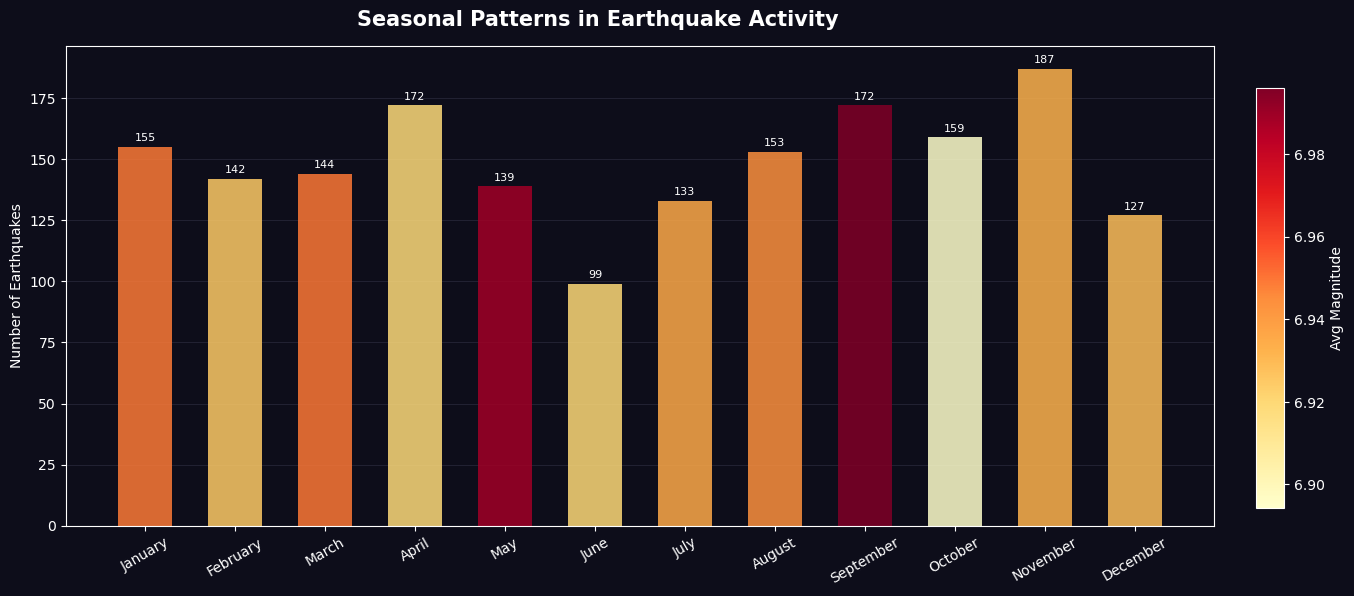

In [8]:
# Seasonal Chart

seasonal = (
    df.groupby('month')
      .agg(earthquake_count=('magnitude', 'count'),
           avg_magnitude=('magnitude', 'mean'))
      .reindex(month_order)
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d0d1a')
ax1.set_facecolor('#0d0d1a')

# bar chart with earthquake count, colored by avg magnitude
norm   = plt.Normalize(seasonal['avg_magnitude'].min(), seasonal['avg_magnitude'].max())
colors = plt.cm.YlOrRd(norm(seasonal['avg_magnitude']))
bars   = ax1.bar(seasonal['month'], seasonal['earthquake_count'],
                 color=colors, width=0.6, alpha=0.85, zorder=2)

# Annotates bars with count
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1.5,
             str(int(bar.get_height())),
             ha='center', va='bottom', color='white', fontsize=8)

ax1.set_xlabel('', fontsize=10)
ax1.set_ylabel('Number of Earthquakes', color='white', fontsize=10)
ax1.tick_params(axis='x', colors='white', rotation=30)
ax1.tick_params(axis='y', colors='white')
ax1.grid(axis='y', color=GRID, linewidth=0.5, zorder=1)
ax1.set_axisbelow(True)

# Colorbar legend to far right
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Avg Magnitude', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

fig.suptitle('Seasonal Patterns in Earthquake Activity', color='white', fontsize=15, fontweight='bold', x=0.45)
plt.subplots_adjust(left=0.07, right=0.89, top=0.92, bottom=0.12)
plt.show()

            mean_cdi  mean_mmi  mean_sig  count
No Tsunami     3.344     6.174   855.722   1153
Tsunami        4.989     5.679   861.196    629


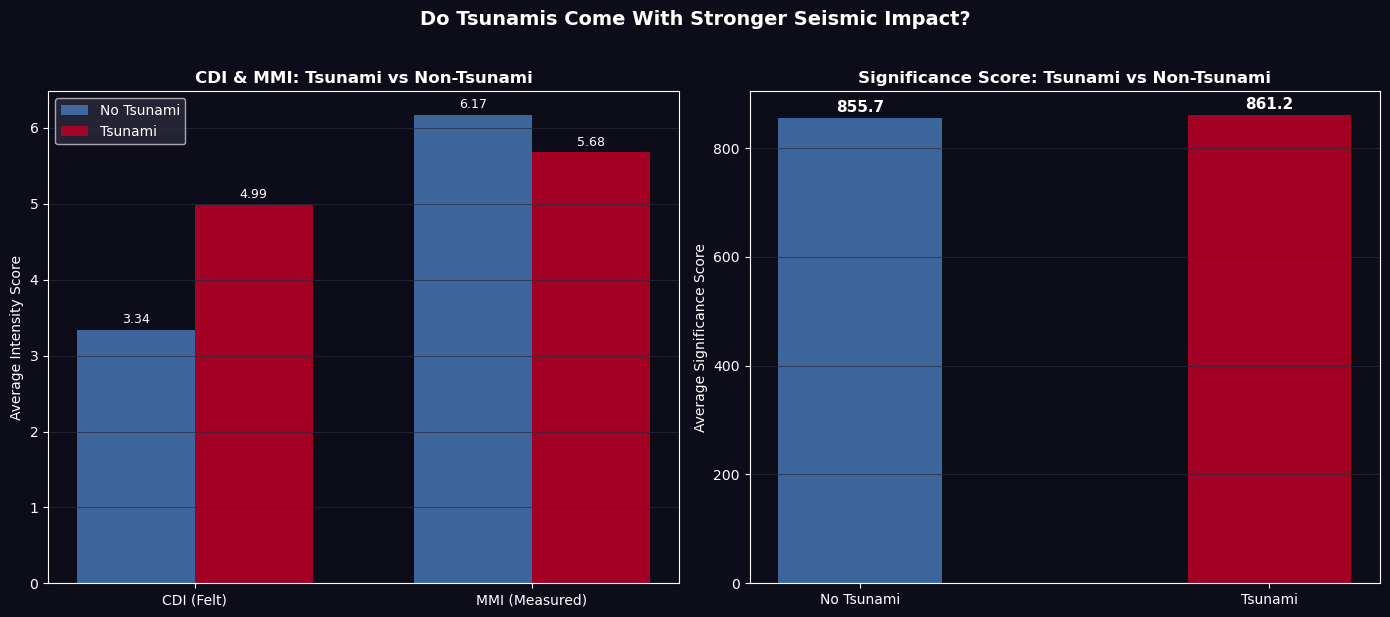

In [ ]:
# Tsunami Agg chart


tsunami_agg = (
    df.groupby('tsunami')
      .agg(mean_cdi=('cdi', 'mean'),
           mean_mmi=('mmi', 'mean'),
           mean_sig=('sig', 'mean'),
           count=('sig', 'count'))
      .round(3)
)
tsunami_agg.index = ['No Tsunami', 'Tsunami']
print(tsunami_agg)

# Melt for grouped bar chart
metrics = tsunami_agg[['mean_cdi', 'mean_mmi']].reset_index()
metrics = metrics.rename(columns={'index': 'tsunami'})  # fix the column name
metrics = metrics.melt(id_vars='tsunami', var_name='Metric', value_name='Value')
metrics['Metric'] = metrics['Metric'].map({'mean_cdi': 'CDI (Felt)', 'mean_mmi': 'MMI (Measured)'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d0d1a')

# Left — CDI vs MMI grouped bars
ax = axes[0]
ax.set_facecolor('#0d0d1a')
palette = {'No Tsunami': ACCENT2, 'Tsunami': RED}
x      = np.arange(len(metrics['Metric'].unique()))
width  = 0.35
groups = metrics['tsunami'].unique()

for i, group in enumerate(groups):
    vals = metrics[metrics['tsunami'] == group]['Value'].values
    bars = ax.bar(x + i * width, vals, width, label=group,
                  color=palette[group], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', color='white', fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics['Metric'].unique(), color='white')
ax.set_ylabel('Average Intensity Score', color='white')
ax.set_title('CDI & MMI: Tsunami vs Non-Tsunami', color='white', fontweight='bold')
ax.tick_params(colors='white')
ax.grid(axis='y', color=GRID, linewidth=0.5)
ax.legend(facecolor='#2a2a3d', labelcolor='white')

# Significance score comparison
ax2 = axes[1]
ax2.set_facecolor('#0d0d1a')
sig_vals  = tsunami_agg['mean_sig'].values
sig_labels = tsunami_agg.index.tolist()
bar_colors = [ACCENT2, RED]
bars2 = ax2.bar(sig_labels, sig_vals, color=bar_colors, width=0.4, alpha=0.85)

for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5,
             f'{bar.get_height():.1f}',
             ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')

ax2.set_ylabel('Average Significance Score', color='white')
ax2.set_title('Significance Score: Tsunami vs Non-Tsunami', color='white', fontweight='bold')
ax2.tick_params(colors='white')
ax2.grid(axis='y', color=GRID, linewidth=0.5)

plt.suptitle('Do Tsunamis Come With Stronger Seismic Impact?',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()